<a href="https://colab.research.google.com/github/abdulmoeedkhan123/Data-analysis-projects/blob/main/Amazon_Data_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# U.S. Amazon purchase 2018-2023.
This notebook analyzes the crowdsourced U.S. Amazon purchase histories dataset with 1.85 million rows and real consumer purchase data 2018-2023 (DOI: 10.7910/DVN/YGLYDY).

###Step 1: Load Data
Load & show sample data>





In [124]:
import pandas as pd
import requests
import io

# Verified file ID for amazon-purchases.csv
file_id = '7616235'
download_url = f'https://dataverse.harvard.edu/api/access/datafile/{file_id}'

print(f"Downloading dataset (ID: {file_id})...")

try:
    response = requests.get(download_url)
    response.raise_for_status()

    # Loading with latin1 encoding as standard for this dataset
    df = pd.read_csv(io.BytesIO(response.content), encoding='latin1')

    print("Data loaded successfully.")
    display(df.head())
    print(f"Dataset contains {df.shape[0]:,} rows and {df.shape[1]} columns.")
except Exception as e:
    print(f"Error loading data: {e}")

Data loaded successfully.


,Order Date,Purchase Price Per Unit,Quantity,Shipping Address State,Title,ASIN/ISBN (Product Code),Category,Survey ResponseID
0,2018-12-04,7.98,1.0,NJ,SanDisk Ultra 16GB Class 10 SDHC UHS-I Memory ...,B0143RTB1E,FLASH_MEMORY,R_01vNIayewjIIKMF
1,2018-12-22,13.99,1.0,NJ,Betron BS10 Earphones Wired Headphones in Ear ...,B01MA1MJ6H,HEADPHONES,R_01vNIayewjIIKMF
2,2018-12-24,8.99,1.0,NJ,NaN,B078JZTFN3,NaN,R_01vNIayewjIIKMF
3,2018-12-25,10.45,1.0,NJ,Perfecto Stainless Steel Shaving Bowl. Durable...,B06XWF9HML,DISHWARE_BOWL,R_01vNIayewjIIKMF
4,2018-12-25,10.00,1.0,NJ,Proraso Shaving Cream for Men,B00837ZOI0,SHAVING_AGENT,R_01vNIayewjIIKMF


Dataset contains 1,850,717 rows and 8 columns.


### Preliminary Data Exploration
Now that the data is loaded, we'll check for info, summary,shape,missing values and general statistics.

In [125]:
# Detailed information about the dataset columns and types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1850717 entries, 0 to 1850716
Data columns (total 8 columns):
 #   Column                    Dtype  
---  ------                    -----  
 0   Order Date                object 
 1   Purchase Price Per Unit   float64
 2   Quantity                  float64
 3   Shipping Address State    object 
 4   Title                     object 
 5   ASIN/ISBN (Product Code)  object 
 6   Category                  object 
 7   Survey ResponseID         object 
dtypes: float64(2), object(6)
memory usage: 113.0+ MB


In [126]:
# Summary of dataset dimensions and missing values
print(f"Dataset shape: {df.shape}")
print("\nMissing values per column:")
display(df.isnull().sum())

Dataset shape: (1850717, 8)

Missing values per column:


,0
Order Date,0
Purchase Price Per Unit,0
Quantity,0
Shipping Address State,87812
Title,89740
ASIN/ISBN (Product Code),973
Category,89458
Survey ResponseID,0


###Step 2: Data Cleaning & Preprocessing

In [127]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

df['Order Date'] = pd.to_datetime(df['Order Date'], errors='coerce')

In [128]:
print(df.isnull().sum())


Order Date                      0
Purchase Price Per Unit         0
Quantity                        0
Shipping Address State      87812
Title                       89740
ASIN/ISBN (Product Code)      973
Category                    89458
Survey ResponseID               0
dtype: int64


In [129]:
# Remove rows with any null values
df = df.dropna()

# Display the updated shape of the dataframe
print(f"New dataset shape: {df.shape}")
print(f"Remaining rows: {df.shape[0]:,}")

New dataset shape: (1675015, 8)
Remaining rows: 1,675,015


/tmp/ipykernel_5265/3826458835.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Total Cost'] = df['Purchase Price Per Unit'] * df['Quantity']
/tmp/ipykernel_5265/3826458835.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['YearMonth'] = df['Order Date'].dt.to_period('M')


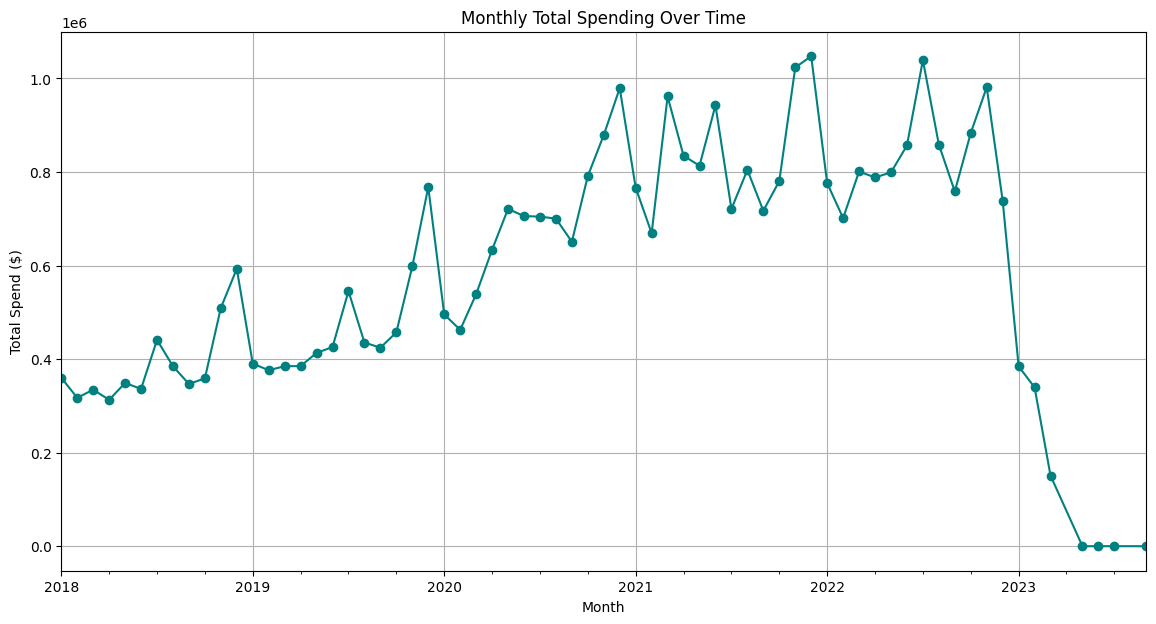

In [130]:
# Analyze spending trends over time
import matplotlib.pyplot as plt

# Fix: Create 'Total Cost' column before grouping
df['Total Cost'] = df['Purchase Price Per Unit'] * df['Quantity']

df['YearMonth'] = df['Order Date'].dt.to_period('M')
monthly_spending = df.groupby('YearMonth')['Total Cost'].sum()

plt.figure(figsize=(14, 7))
monthly_spending.plot(kind='line', marker='o', color='teal')
plt.title('Monthly Total Spending Over Time')
plt.xlabel('Month')
plt.ylabel('Total Spend ($)')
plt.grid(True)
plt.show()

/tmp/ipykernel_5265/3613647757.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Total Cost'] = df['Purchase Price Per Unit'] * df['Quantity']


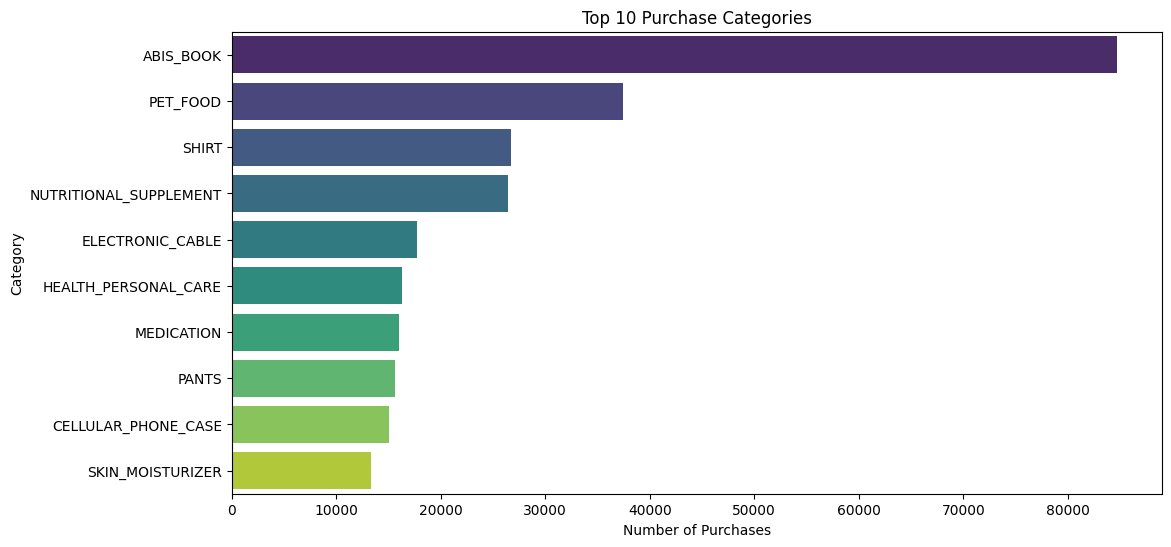

In [131]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate total cost per entry
df['Total Cost'] = df['Purchase Price Per Unit'] * df['Quantity']

# Visualize top 10 categories with updated seaborn syntax
plt.figure(figsize=(12, 6))
top_categories = df['Category'].value_counts().head(10)
sns.barplot(x=top_categories.values, y=top_categories.index, hue=top_categories.index, palette='viridis', legend=False)
plt.title('Top 10 Purchase Categories')
plt.xlabel('Number of Purchases')
plt.ylabel('Category')
plt.show()

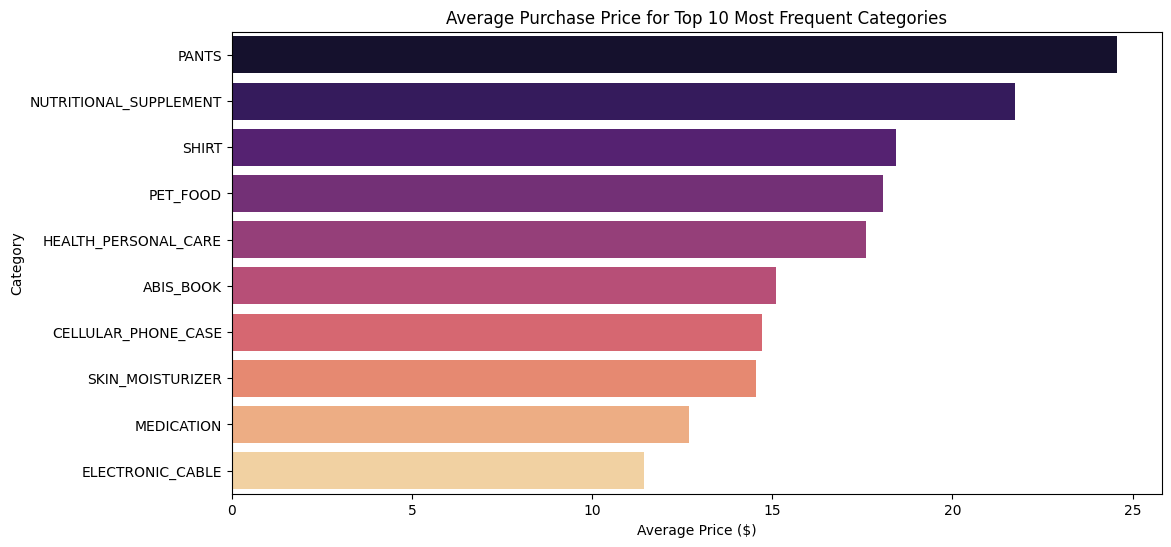

In [132]:
# Analyze average price per unit for the top 10 most frequent categories
top_10_cat_names = top_categories.index.tolist()
avg_price_cat = df[df['Category'].isin(top_10_cat_names)].groupby('Category')['Purchase Price Per Unit'].mean().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x=avg_price_cat.values, y=avg_price_cat.index, hue=avg_price_cat.index, palette='magma', legend=False)
plt.title('Average Purchase Price for Top 10 Most Frequent Categories')
plt.xlabel('Average Price ($)')
plt.ylabel('Category')
plt.show()

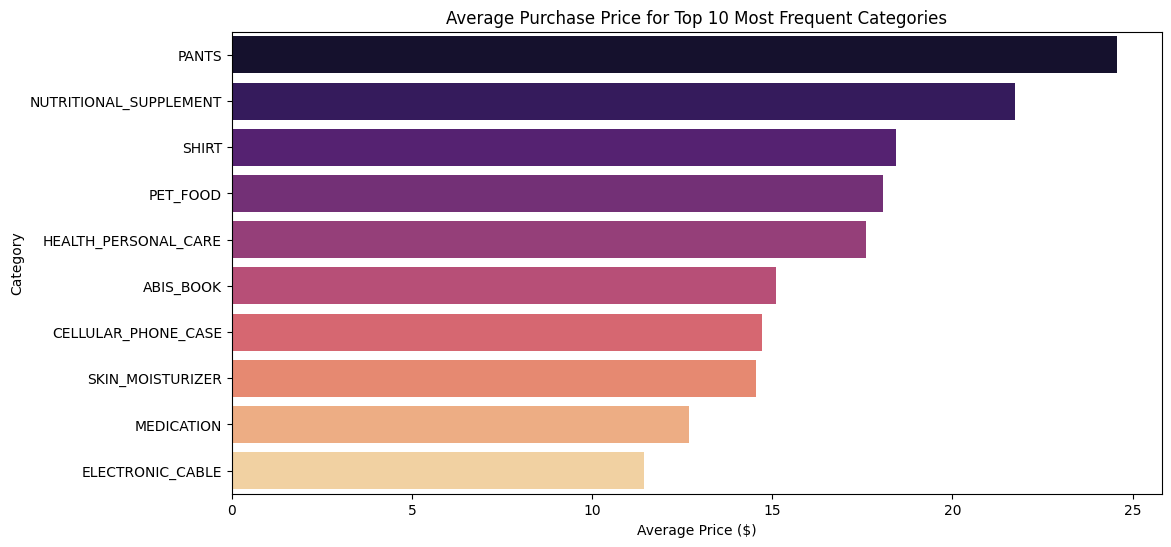

In [133]:
# Analyze average price per unit for the top 10 most frequent categories
top_10_cat_names = top_categories.index.tolist()
avg_price_cat = df[df['Category'].isin(top_10_cat_names)].groupby('Category')['Purchase Price Per Unit'].mean().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x=avg_price_cat.values, y=avg_price_cat.index, hue=avg_price_cat.index, palette='magma', legend=False)
plt.title('Average Purchase Price for Top 10 Most Frequent Categories')
plt.xlabel('Average Price ($)')
plt.ylabel('Category')
plt.show()

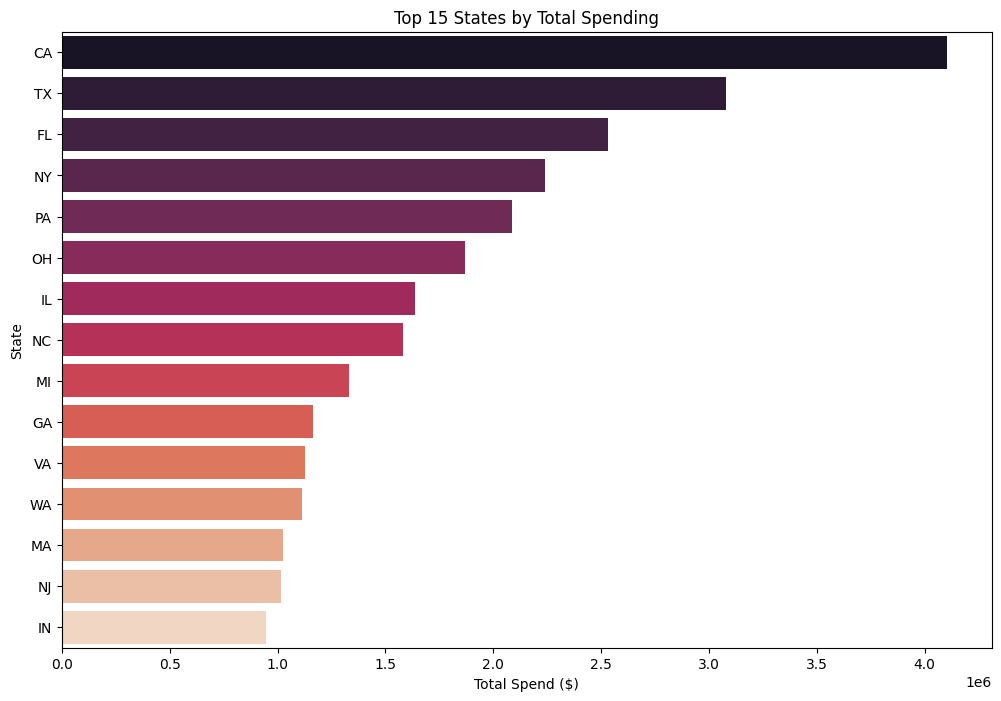

In [134]:
# Analyze total spending by State
state_spending = df.groupby('Shipping Address State')['Total Cost'].sum().sort_values(ascending=False).head(15)

plt.figure(figsize=(12, 8))
sns.barplot(x=state_spending.values, y=state_spending.index, hue=state_spending.index, palette='rocket', legend=False)
plt.title('Top 15 States by Total Spending')
plt.xlabel('Total Spend ($)')
plt.ylabel('State')
plt.show()

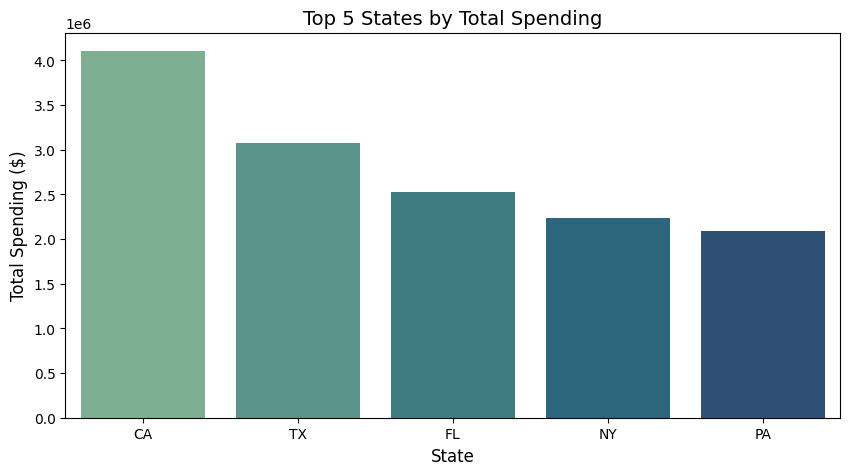

Top 5 States and their total spending:
Shipping Address State
CA    $4,105,586.55
TX    $3,076,774.65
FL    $2,531,409.82
NY    $2,238,773.86
PA    $2,087,735.27
Name: Total Cost, dtype: object


In [135]:
# Calculate top 5 states by total spending
top_5_states = df.groupby('Shipping Address State')['Total Cost'].sum().sort_values(ascending=False).head(5)

# Visualization
plt.figure(figsize=(10, 5))
sns.barplot(x=top_5_states.index, y=top_5_states.values, hue=top_5_states.index, palette='crest', legend=False)
plt.title('Top 5 States by Total Spending', fontsize=14)
plt.xlabel('State', fontsize=12)
plt.ylabel('Total Spending ($)', fontsize=12)
plt.show()

print("Top 5 States and their total spending:")
print(top_5_states.apply(lambda x: f"${x:,.2f}"))

In [138]:
# Calculate Total Sales (new column)
df['Total Sales'] = df['Purchase Price Per Unit'] * df['Quantity']

print(f"Date range: {df['Order Date'].min()} to {df['Order Date'].max()}")


Date range: 2018-01-01 00:00:00 to 2023-09-01 00:00:00


Step 1: Data Cleaning & Preprocessing


/tmp/ipykernel_5265/903952270.py:10: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  yoy_growth = monthly_by_year.pct_change(axis=1) * 100


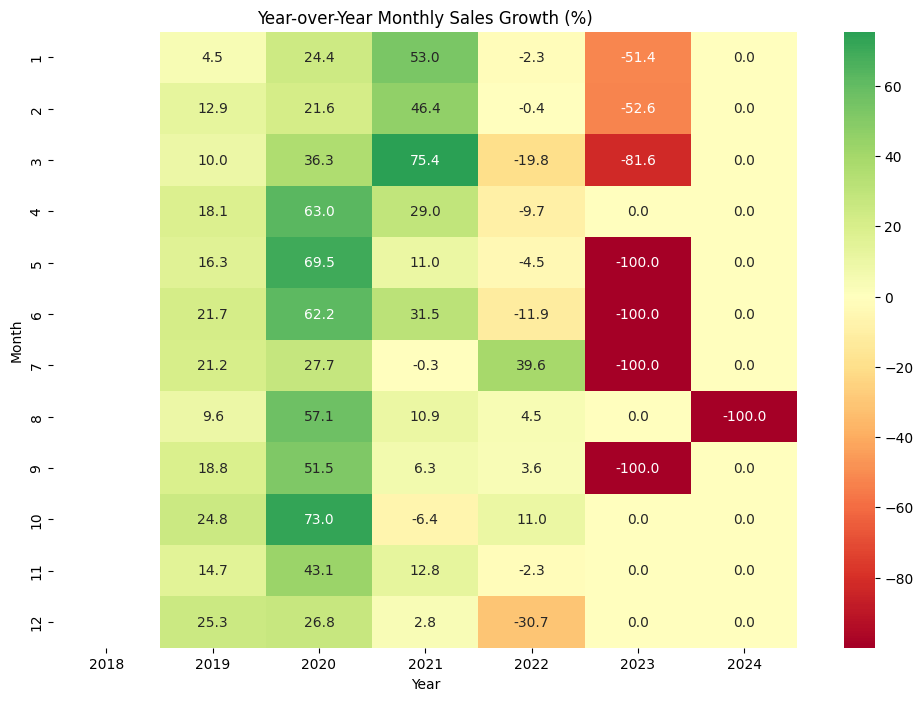

In [140]:
# Extract year and month
df_sales['Year'] = df_sales['Order Date'].dt.year
df_sales['Month'] = df_sales['Order Date'].dt.month
df_sales['YearMonth'] = df_sales['Order Date'].dt.to_period('M')

# Monthly sales by year
monthly_by_year = df_sales.groupby(['Year', 'Month'])['Total Sales'].sum().unstack(level=0)

# Calculate YoY growth
yoy_growth = monthly_by_year.pct_change(axis=1) * 100

# Heatmap of YoY growth
plt.figure(figsize=(12, 8))
sns.heatmap(yoy_growth, annot=True, fmt='.1f', cmap='RdYlGn', center=0)
plt.title('Year-over-Year Monthly Sales Growth (%)')
plt.xlabel('Year')
plt.ylabel('Month')
plt.show()

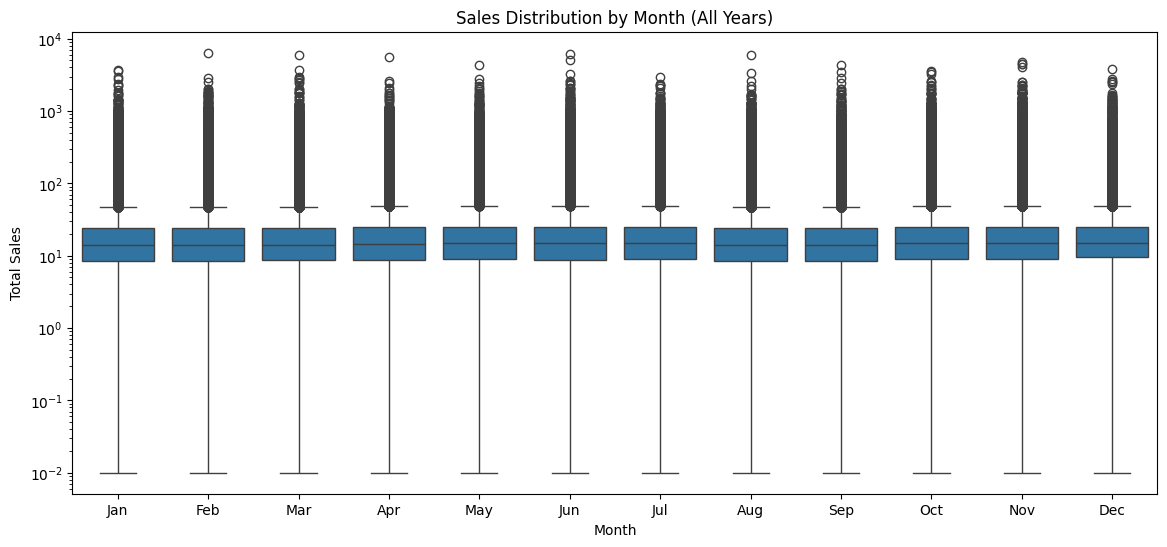

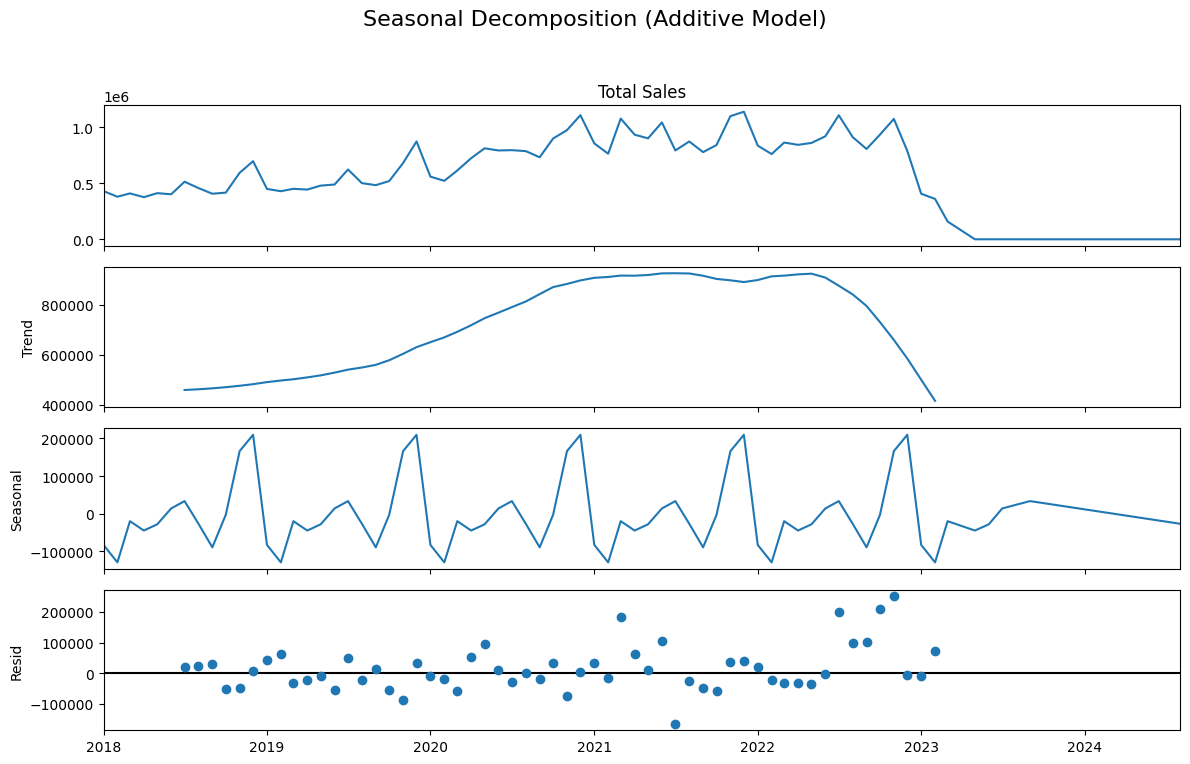

In [142]:
# Monthly pattern across all years
monthly_pattern = df_sales.groupby('Month')['Total Sales'].agg(['mean', 'median', 'std'])

# Boxplot by month
plt.figure(figsize=(14, 6))
sns.boxplot(x='Month', y='Total Sales', data=df_sales)
plt.title('Sales Distribution by Month (All Years)')
plt.xticks(range(12), ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])
plt.yscale('log')
plt.show()

# Seasonal decomposition
from statsmodels.tsa.seasonal import seasonal_decompose

# Prepare monthly series and remove trailing months with 0 sales (like in 2024)
monthly_ts = monthly_sales[monthly_sales > 0].copy()
monthly_ts.index = monthly_ts.index.to_period('M').to_timestamp()

# Fix: Use 'additive' model because multiplicative cannot handle the 0.0 values in the series
decomposition = seasonal_decompose(monthly_ts, model='additive', period=12)
fig = decomposition.plot()
fig.set_size_inches(12, 8)
plt.suptitle('Seasonal Decomposition (Additive Model)', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

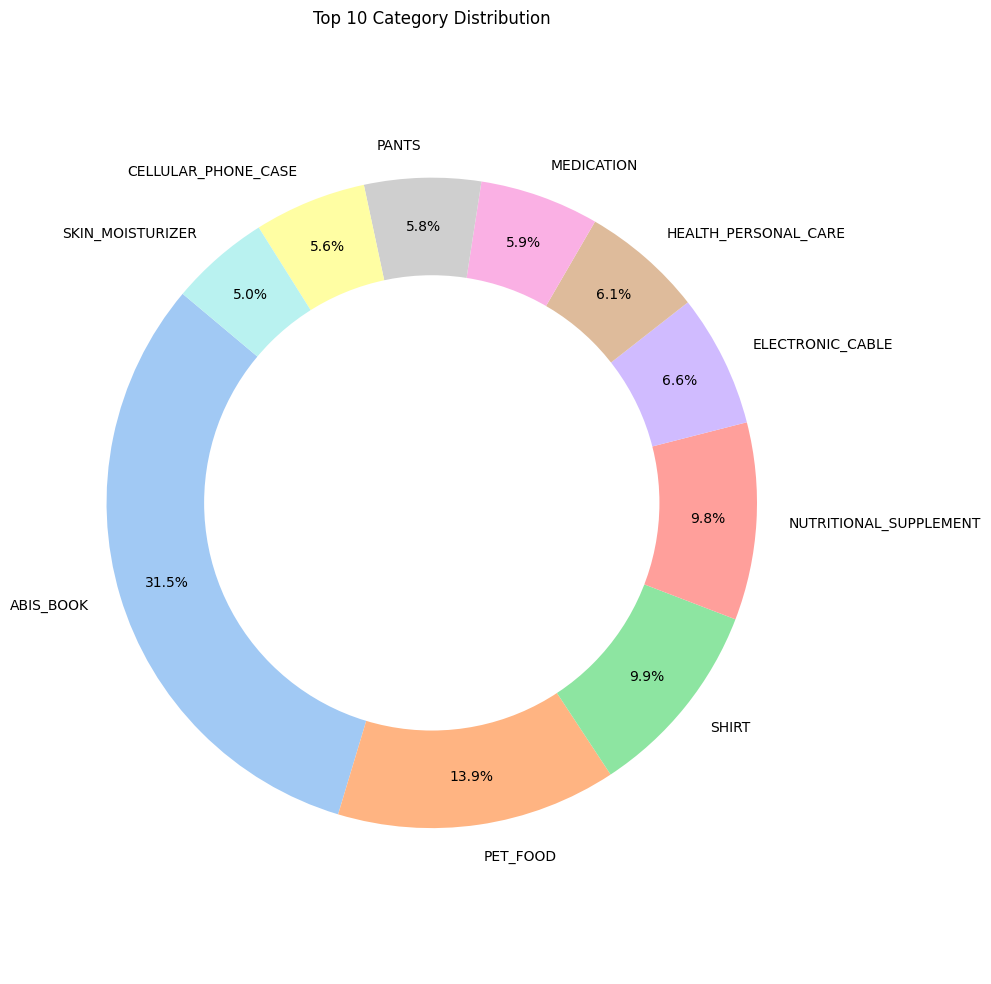

In [143]:
# Visualize the distribution of the Top 10 categories using a pie chart
top_10_categories = df['Category'].value_counts().head(10)

plt.figure(figsize=(10, 10))
plt.pie(
    top_10_categories.values,
    labels=top_10_categories.index,
    autopct='%1.1f%%',
    startangle=140,
    colors=sns.color_palette('pastel'),
    pctdistance=0.85
)

# Draw a circle at the center to turn the pie into a donut (optional but looks modern)
centre_circle = plt.Circle((0,0), 0.70, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title('Top 10 Category Distribution')
plt.axis('equal')
plt.tight_layout()
plt.show()

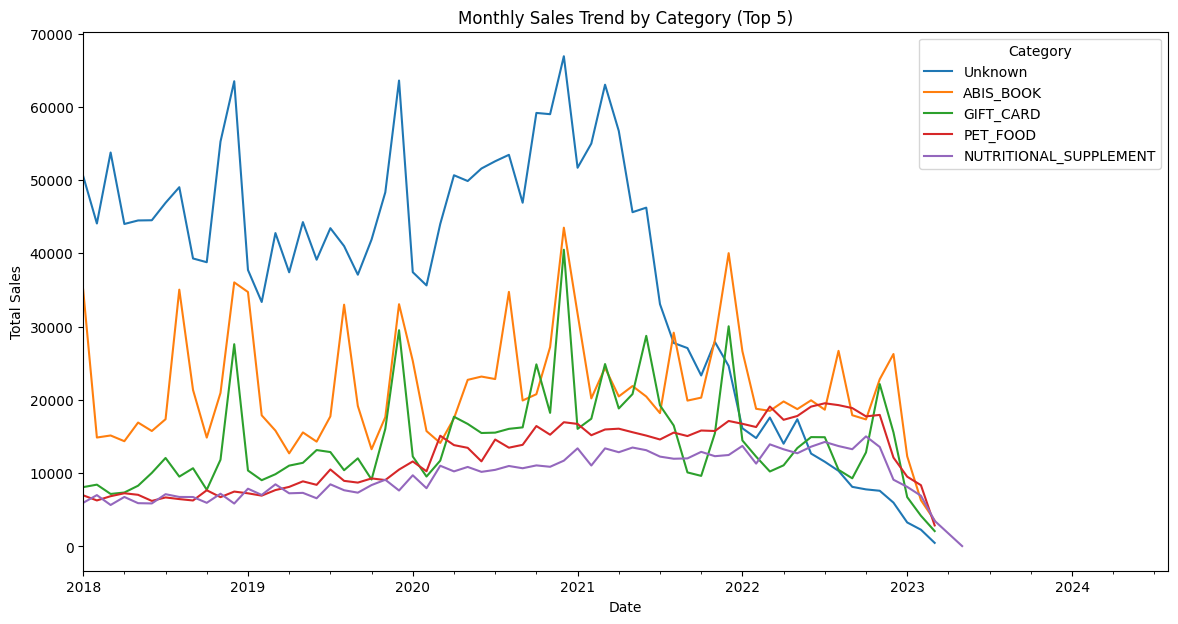

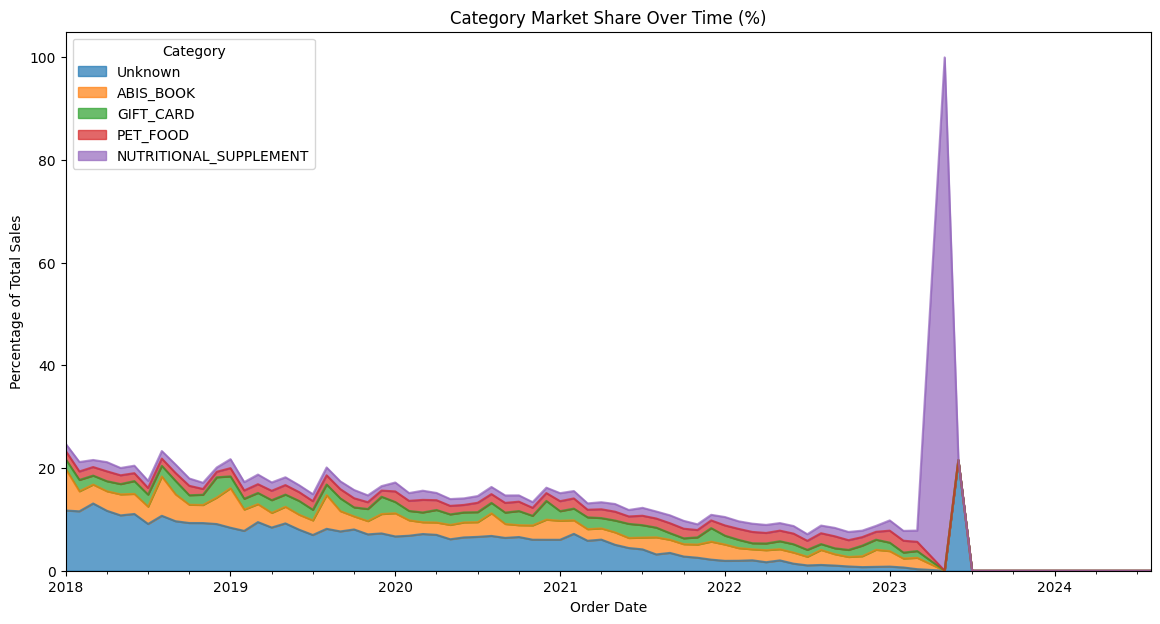

In [144]:
# Category sales over time
category_trend = df_sales.groupby([df_sales['Order Date'].dt.to_period('M'), 'Category'])['Total Sales'].sum().unstack(level=1)

# Plot top 5 categories
top_categories = df_sales.groupby('Category')['Total Sales'].sum().nlargest(5).index
category_trend[top_categories].plot(figsize=(14, 7))
plt.title('Monthly Sales Trend by Category (Top 5)')
plt.xlabel('Date')
plt.ylabel('Total Sales')
plt.legend(title='Category')
plt.show()

# Category market share over time (stacked area)
category_trend_pct = category_trend.div(category_trend.sum(axis=1), axis=0) * 100
category_trend_pct[top_categories].plot(kind='area', figsize=(14, 7), stacked=True, alpha=0.7)
plt.title('Category Market Share Over Time (%)')
plt.ylabel('Percentage of Total Sales')
plt.show()

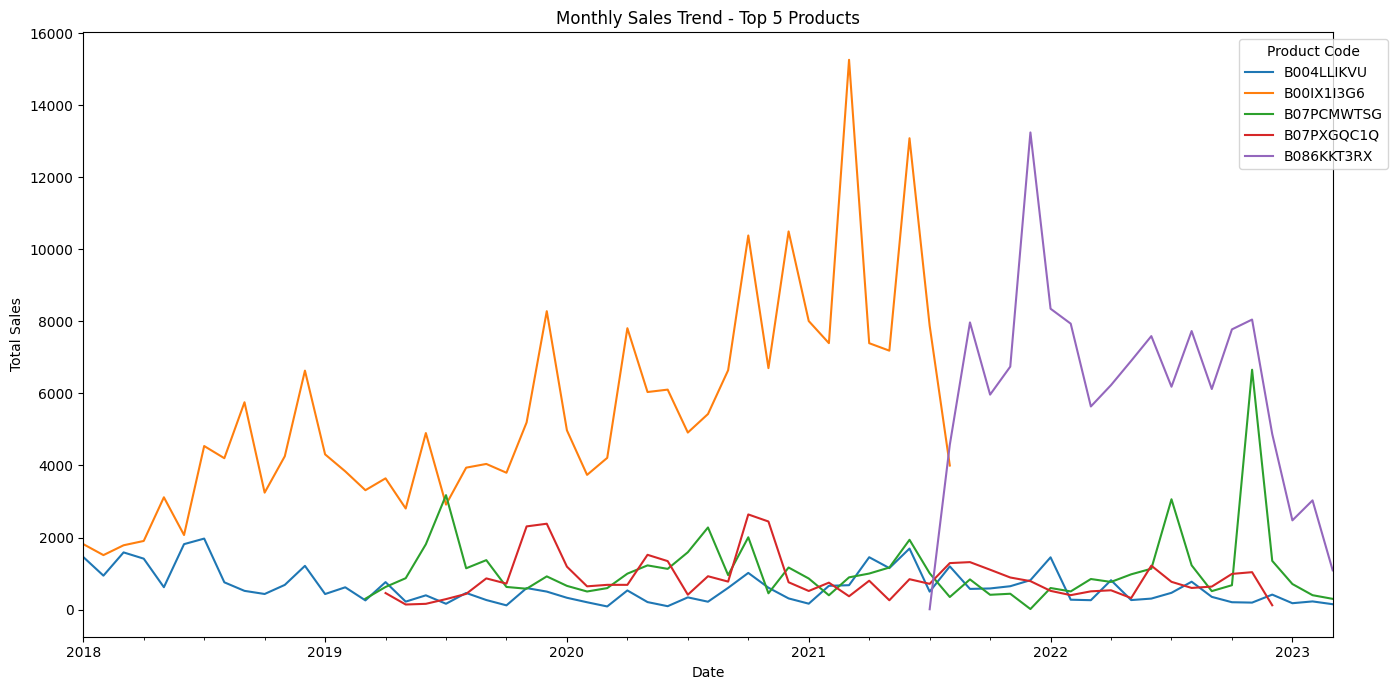

In [145]:
# Top 10 products by total sales
top_products = df_sales.groupby('Title')['Total Sales'].sum().nlargest(10)

# Monthly trend for top 5 products
top_5_asins = df_sales.groupby('ASIN/ISBN (Product Code)')['Total Sales'].sum().nlargest(5).index
top_products_trend = df_sales[df_sales['ASIN/ISBN (Product Code)'].isin(top_5_asins)].groupby([
    df_sales['Order Date'].dt.to_period('M'),
    'ASIN/ISBN (Product Code)'
])['Total Sales'].sum().unstack(level=1)

top_products_trend.plot(figsize=(14,7))
plt.title('Monthly Sales Trend - Top 5 Products')
plt.xlabel('Date')
plt.ylabel('Total Sales')
plt.legend(title='Product Code', bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

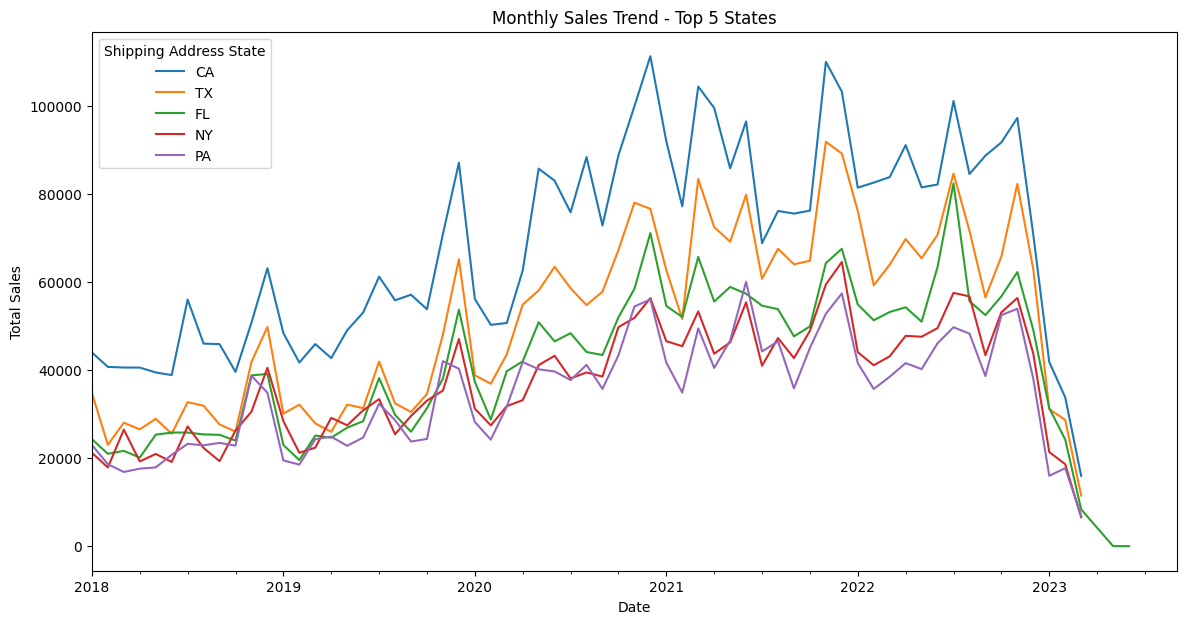

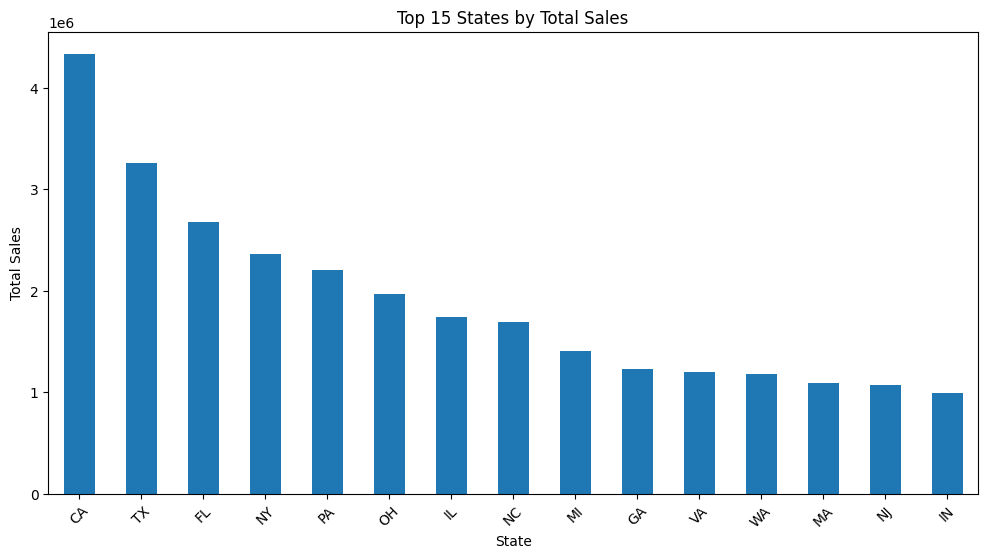

In [146]:
# State-level sales over time
state_sales = df_sales.groupby([df_sales['Order Date'].dt.to_period('M'), 'Shipping Address State'])['Total Sales'].sum().unstack(level=1)

# Top 10 states by total sales
top_states = df_sales.groupby('Shipping Address State')['Total Sales'].sum().nlargest(10).index

# Plot top 5 states trend
state_sales[top_states[:5]].plot(figsize=(14,7))
plt.title('Monthly Sales Trend - Top 5 States')
plt.xlabel('Date')
plt.ylabel('Total Sales')
plt.show()

# Geographic heatmap (requires state coordinates)
state_summary = df_sales.groupby('Shipping Address State').agg({
    'Total Sales': 'sum',
    'Quantity': 'sum',
    'Order Date': 'count'
}).rename(columns={'Order Date': 'Number of Transactions'})

# Calculate average order value by state
state_summary['Avg Order Value'] = state_summary['Total Sales'] / state_summary['Number of Transactions']

# If you have state abbreviations (CA, TX, NY, etc.), you can create a choropleth map
# For now, sort and visualize
state_summary_sorted = state_summary.sort_values('Total Sales', ascending=False).head(15)
state_summary_sorted['Total Sales'].plot(kind='bar', figsize=(12,6))
plt.title('Top 15 States by Total Sales')
plt.xlabel('State')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.show()

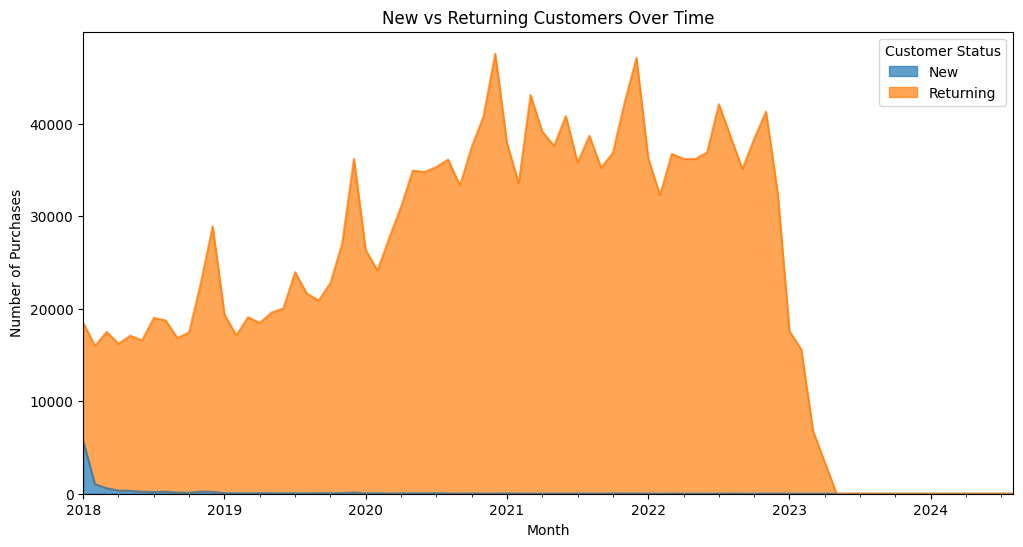

In [147]:
# Check customer purchase patterns
customer_stats = df_sales.groupby('Survey ResponseID').agg({
    'Total Sales': 'sum',
    'Quantity': 'sum',
    'Order Date': ['count', 'min', 'max']
}).round(2)

customer_stats.columns = ['Total Spent', 'Total Items', 'Purchase Count', 'First Purchase', 'Last Purchase']
customer_stats['Customer Tenure (days)'] = (customer_stats['Last Purchase'] - customer_stats['First Purchase']).dt.days

# Segment customers by purchase frequency
customer_stats['Segment'] = pd.cut(customer_stats['Purchase Count'],
                                   bins=[0, 1, 3, 10, float('inf')],
                                   labels=['One-time', 'Occasional (2-3)', 'Regular (4-10)', 'Frequent (>10)'])

# Trend of new vs returning customers over time
df_sales['Customer Status'] = df_sales.groupby('Survey ResponseID')['Order Date'].transform(
    lambda x: (x == x.min()).map({True: 'New', False: 'Returning'})
)

customer_status_trend = df_sales.groupby([df_sales['Order Date'].dt.to_period('M'), 'Customer Status']).size().unstack(level=1)
customer_status_trend.plot(kind='area', figsize=(12,6), stacked=True, alpha=0.7)
plt.title('New vs Returning Customers Over Time')
plt.ylabel('Number of Purchases')
plt.xlabel('Month')
plt.show()

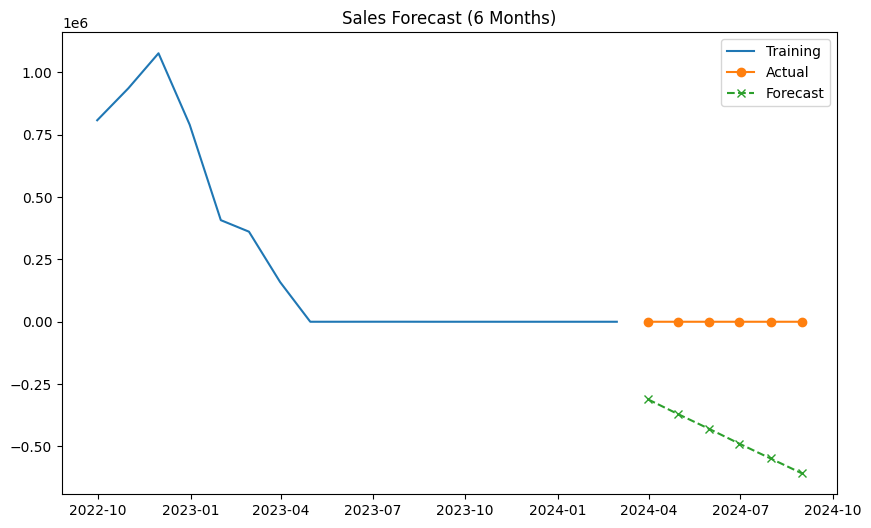

MAE: $459,321.88
RMSE: $470,350.18


In [148]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Simple forecast: use monthly sales from last 2 years
monthly_ts = monthly_sales.tail(24)
train = monthly_ts[:-6]  # last 6 months for testing
test = monthly_ts[-6:]

# Train simple model
X_train = np.arange(len(train)).reshape(-1, 1)
y_train = train.values
model = LinearRegression()
model.fit(X_train, y_train)

# Predict next 6 months
X_test = np.arange(len(train), len(train) + len(test)).reshape(-1, 1)
predictions = model.predict(X_test)

# Plot
plt.figure(figsize=(10,6))
plt.plot(train.index, train.values, label='Training')
plt.plot(test.index, test.values, label='Actual', marker='o')
plt.plot(test.index, predictions, label='Forecast', linestyle='--', marker='x')
plt.title('Sales Forecast (6 Months)')
plt.legend()
plt.show()

print(f"MAE: ${mean_absolute_error(test, predictions):,.2f}")
print(f"RMSE: ${np.sqrt(mean_squared_error(test, predictions)):,.2f}")

In [149]:
# Calculate YoY growth by state
state_yearly = df_sales.groupby(['Shipping Address State', 'Year'])['Total Sales'].sum().unstack(level=1)
state_growth = state_yearly.pct_change(axis=1) * 100

# Find fastest growing and declining states
fastest_growing = state_growth.iloc[:, -1].nlargest(10).dropna()
fastest_declining = state_growth.iloc[:, -1].nsmallest(10).dropna()

print("Fastest Growing States (YoY):")
print(fastest_growing)
print("\nFastest Declining States (YoY):")
print(fastest_declining)

Fastest Growing States (YoY):
Shipping Address State
PR     0.000000
AK   -84.477768
DC   -84.936315
IA   -87.125363
KY   -87.742096
VT   -88.203466
WI   -88.881537
MS   -89.033393
MI   -89.359453
AZ   -89.412245
Name: 2023, dtype: float64

Fastest Declining States (YoY):
Shipping Address State
WY   -99.332316
ND   -98.861393
SD   -98.533381
RI   -98.074230
MT   -97.185112
HI   -96.020274
ME   -95.803875
AR   -94.662273
UT   -94.032156
AL   -93.486864
Name: 2023, dtype: float64


/tmp/ipykernel_5265/613511347.py:3: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  state_growth = state_yearly.pct_change(axis=1) * 100


In [159]:
# 4. Update the remote with your Personal Access Token and Push
# IMPORTANT: Replace YOUR_ACTUAL_TOKEN_HERE with your real token from GitHub
TOKEN = 'YOUR_ACTUAL_TOKEN_HERE'
REPO_URL = 'github.com/abdulmoeedkhan123/Data-analysis-projects.git'

# Re-configure the remote URL to include the token for authentication
!git remote set-url origin https://{TOKEN}@{REPO_URL}

# Try pushing to 'master' (or change to 'main' if that is your default branch)
!git push -u origin master

fatal: could not read Password for 'https://YOUR_ACTUAL_TOKEN_HERE@github.com': No such device or address


### Authentication Note
If you receive an authentication error, you can include your Personal Access Token (PAT) directly in the URL:
```bash
!git remote set-url origin https://<git_TOKEN>@github.com/abdulmoeedkhan123/Data-analysis-projects.git
!git push -u origin master
```